For 2021-2023 data only. 

#### Getting count of applicants 

In [2]:
import pandas as pd 

# importing data set 
df = pd.read_csv('2021-2023chapa.csv')

# counting how many applicants applied to multiple properties 
repeated_ids = (df['ID Number'].value_counts() > 1).sum()
print("Number of repeated IDs:", repeated_ids)

# counting total number of applicants 
id_count = (df['ID Number'].value_counts()).sum()
print('Total amount of applications:', id_count)

Number of repeated IDs: 35
Total amount of applications: 380


#### Analyzing applicant demographics 

In [3]:
all_applicants = df

# get ids that appear more than once
id_counts = df['ID Number'].value_counts()
repeat_ids = id_counts[id_counts > 1].index

# creating a subset of repeat applicants 
repeat_applicants = df[df['ID Number'].isin(repeat_ids)].drop_duplicates(subset = 'ID Number')

# getting demographics of applicants who applied multiple times and all applicants 
race_repeat_counts = repeat_applicants['Census Race'].value_counts()
race_all_counts = all_applicants['Census Race'].value_counts()

# seeing values 
print('Repeat Applicant Demographics:')
print(race_repeat_counts)
print('All Applicant Demographics:')
print(race_all_counts)

Repeat Applicant Demographics:
Census Race
White alone                        21
Black or African American alone     7
Asian alone                         5
Unknown                             2
Name: count, dtype: int64
All Applicant Demographics:
Census Race
White alone                                217
Unknown                                     67
Asian alone                                 45
Black or African American alone             45
White; Black or African American             3
American Indian and Alaska Native alone      2
Some Other Race alone                        1
Name: count, dtype: int64


#### Creating visualizations 

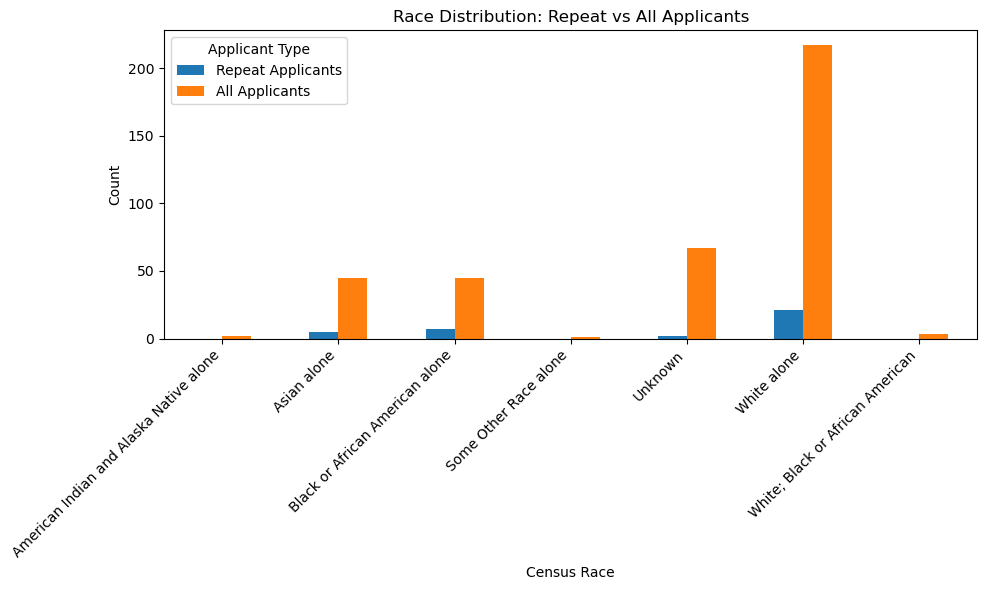

In [ ]:
import matplotlib.pyplot as plt

# combine into one DataFrame for plotting
race_compare = pd.DataFrame({
    'Repeat Applicants': race_repeat_counts,
    'All Applicants': race_all_counts
# replace missing races with 0 counts
}).fillna(0)  

# plot side by side bars  
race_compare.plot(kind = 'bar', figsize = (10,6))
plt.title('Race Distribution: Repeat vs All Applicants')
plt.xlabel('Census Race')
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.legend(title = 'Applicant Type')
plt.tight_layout()
plt.show()

This graph shows the race distribution between repeat applicants vs. all applicants. White and Black applicants have the highest frequency of repeat applications. 

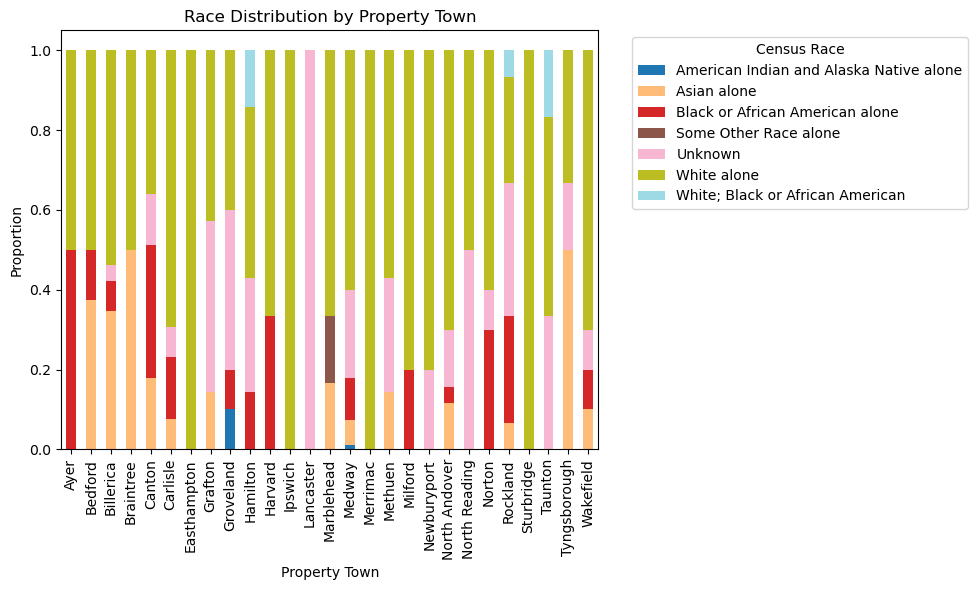

In [ ]:
# combine into one DataFrame for plotting
race_prop = (
    df.groupby('Property Town')['Census Race']
      .value_counts(normalize = True)
      .unstack(fill_value = 0)
)

# plot proportion of the applicant demographics to where they applied to 
race_prop.plot(kind = 'bar', stacked = True, figsize = (10,6), colormap = 'tab20')
plt.title('Race Distribution by Property Town')
plt.xlabel('Property Town')
plt.ylabel('Proportion')
plt.legend(title = 'Census Race', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

This graph shows the race distribution by property town. Easthampton, Ipswich, Merrimac, and Ayer had the highest numbers of White and Black applicants, respectively.